# Volve 7 — all wells, nodal analysis, gathering network, and full SURF

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/fielddevelopment/volve/07_volve_all_wells_gathering_surf.ipynb)

**Notebook 7 — Volve field-calculation extension**

The authoritative measured-data boundary is Equinor's Volve Data
Village listing in Databricks Marketplace. Normal execution reads
an installed Unity Catalog Volume and never stores credentials or
redistributes the source package.

The retained clean-runtime output uses an explicitly requested,
deterministic teaching fixture. Every such output is marked
**DEMONSTRATION_FALLBACK**. It is not measured Volve production, a
history match, a reserves statement, or a design certification.


## Learning outcomes and engineering decisions

            - simulate every active producer instead of using one representative well
- combine IPR, tubing VLP, choke loss, and network backpressure in nodal analysis
- derive wellstream phase behavior and hydraulic coefficients with NeqSim
- solve two manifolds, branches, trunks, a common riser, and host pressure together
- verify the coupled solution with a composable NeqSim ProcessSystem
- screen flow regime, liquid holdup, velocity, erosion, FIV, and thermal margins
- compare peak, mature, late-life, well-outage, and turndown operating cases
- evaluate controlled shutdown, cooldown, hydrate exposure, and restart ramps
- connect production technology and SURF decisions to the full field lifecycle

            The notebook writes a versioned contract so later calculations
            consume named quantities, units, provenance, fitted parameters,
            validity limits, and uncertainty rather than hidden state.


## Data provenance and licence

Primary sources and software:

- [Databricks Marketplace: Equinor Volve Data Village](https://marketplace.databricks.com/details/5c3558ef-315c-44dd-baef-7062ac301f22/Equinor-ASA_Volve-Data-Village)
- [Equinor Volve data sharing](https://www.equinor.com/energy/volve-data-sharing)
- [Equinor Volve open-data licence](https://www.equinor.com/content/dam/statoil/documents/what-we-do/Equinor-HRS-Terms-and-conditions-for-licence-to-data-Volve.pdf)
- [OPM Flow](https://opm-project.org/?page_id=19)
- [NeqSim](https://github.com/equinor/neqsim)
- [NeqSim Field Development and Operations book](https://equinor.github.io/neqsimhome/doc/field_development_and_operations/book_standalone.html)

Equinor states that the release contains subsurface, production,
and operating data from the 2008–2016 production period. The
notebook selects only the production workbook and, when requested,
one reservoir deck with its controlled include directory. The book
supplies the lifecycle and production-technology learning spine;
this Volve series applies those topics to one traceable field case.


## Clean-runtime setup and source policy

Normal Colab execution installs the Python bridges, clones current
`equinor/neqsim` master, records the resolved commit, builds the
runtime JAR, and verifies the loaded Java class origin. Local
validation sets `VOLVE_VALIDATION_MODE=1` and uses the pinned
NeqSim 3.17.0 release JAR. The validation runtime proves notebook
logic, but it does not replace the required current-master and
authenticated Marketplace acceptance runs.


In [1]:
from importlib.metadata import version
import hashlib
import json
import math
import os
from pathlib import Path
import platform
import shutil
import subprocess
import sys


VALIDATION_MODE = os.environ.get("VOLVE_VALIDATION_MODE") == "1"
NEQSIM_SOURCE_REF = os.environ.get("NEQSIM_SOURCE_REF", "master")
NEQSIM_REPOSITORY_URL = "https://github.com/equinor/neqsim"

if not VALIDATION_MODE:
    packages = [
        "neqsim==3.17.0",
        "databricks-sdk==0.72.0",
        "openpyxl==3.1.5",
        "xlrd==2.0.2",
    ]
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "--quiet", *packages],
        check=True,
        timeout=900,
    )
    source_dir = Path("/content/neqsim-master")
    if not source_dir.exists():
        subprocess.run(
            [
                "git",
                "clone",
                "--depth",
                "1",
                "--branch",
                NEQSIM_SOURCE_REF,
                NEQSIM_REPOSITORY_URL,
                str(source_dir),
            ],
            check=True,
            timeout=300,
        )
    resolved_commit = subprocess.run(
        ["git", "-C", str(source_dir), "rev-parse", "HEAD"],
        capture_output=True,
        check=True,
        text=True,
        timeout=60,
    ).stdout.strip()
    subprocess.run(
        [str(source_dir / "mvnw"), "-q", "-DskipTests", "package"],
        check=True,
        cwd=source_dir,
        timeout=1800,
    )
    runtime_jars = sorted(
        (source_dir / "target").glob(
            "neqsim-*-jar-with-dependencies.jar"
        )
    )
    if not runtime_jars:
        raise RuntimeError("Current-master NeqSim JAR was not built.")
    os.environ["NEQSIM_JVM_AUTOSTART"] = "false"
    import jpype

    jpype.addClassPath(str(runtime_jars[-1]))
    jpype.startJVM(convertStrings=False)
else:
    resolved_commit = "release-3.17.0-validation-runtime"

from neqsim import jneqsim
from neqsim.thermo import TPflash

protection = (
    jneqsim.thermo.system.SystemSrkEos.class_
    .getProtectionDomain()
    .getCodeSource()
)
runtime_origin = str(protection.getLocation()) if protection else "bundled JAR"
print(
    {
        "Python": platform.python_version(),
        "NeqSim bridge": version("neqsim"),
        "NeqSim source ref": NEQSIM_SOURCE_REF,
        "resolved commit": resolved_commit,
        "runtime origin": runtime_origin,
        "validation mode": VALIDATION_MODE,
    }
)


{'Python': '3.12.13', 'NeqSim bridge': '3.17.0', 'NeqSim source ref': 'master', 'resolved commit': 'release-3.17.0-validation-runtime', 'runtime origin': 'None', 'validation mode': True}


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.optimize import brentq, least_squares

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 120

series_dir = Path.cwd()
if not (series_dir / "volve_common.py").is_file():
    repository_dir = Path("/content/NeqSim-Colab")
    if not repository_dir.exists():
        subprocess.run(
            [
                "git",
                "clone",
                "--depth",
                "1",
                "https://github.com/EvenSol/NeqSim-Colab.git",
                str(repository_dir),
            ],
            check=True,
            timeout=300,
        )
    series_dir = (
        repository_dir
        / "notebooks"
        / "fielddevelopment"
        / "volve"
    )
sys.path.insert(0, str(series_dir))

import volve_common as vc

work_dir = Path(
    os.environ.get("VOLVE_WORK_DIR", str(series_dir / "work"))
)
work_dir.mkdir(parents=True, exist_ok=True)
source = vc.resolve_source()
display(vc.source_table(source))


,item,value
0,resolved mode,demonstration-fallback
1,Marketplace listing,https://marketplace.databricks.com/details/5c3...
2,volume root,not mounted
3,credentials,none
4,measured Volve data loaded,False
5,claim boundary,Deterministic teaching fixtures are used. Resu...


## Marketplace inventory and bounded production selection

Set `VOLVE_DATA_MODE=marketplace` and provide either:

1. `VOLVE_VOLUME_ROOT` for a mounted or exported Volume; or
2. `VOLVE_REMOTE_VOLUME_ROOT` plus `DATABRICKS_HOST` and
   `DATABRICKS_TOKEN` in Colab Secrets.

`VOLVE_PRODUCTION_PATH` identifies the production workbook. Remote
execution downloads only that selected file. The token is never
printed, written to a contract, or retained in notebook output.


In [3]:
if source.mode == "marketplace-local-volume":
    inventory = vc.inventory_local_volume(Path(source.volume_root))
elif source.mode == "marketplace-remote-volume":
    inventory = vc.list_remote_directory(source.volume_root)
else:
    inventory = vc.demonstration_inventory()

production_candidates = inventory.loc[
    inventory["domain"].eq("production-history"),
    ["relative_path", "bytes"],
].copy()
display(production_candidates.head(20))

if source.measured_data_loaded:
    production_relative_path = vc.select_asset(
        inventory,
        "production-history",
        environment_name="VOLVE_PRODUCTION_PATH",
    )
    production_path = vc.materialize_asset(
        source,
        inventory,
        production_relative_path,
        work_dir / "marketplace_inputs",
    )
    production = vc.read_production_history(production_path)
    production_provenance = dict(production.attrs)
else:
    production_relative_path = "DEMONSTRATION_FALLBACK"
    production = vc.demo_production_history()
    production_provenance = {
        "source_path": "deterministic teaching fixture",
        "source_sha256": None,
        "sheet_name": None,
        "raw_rows": len(production),
        "normalized_rows": len(production),
    }

display(pd.DataFrame([production_provenance]))
display(production.head())
print(
    {
        "wells": sorted(production["well"].unique()),
        "rows": len(production),
        "data status": production["data_status"].unique().tolist(),
    }
)


{'wells': ['15/9-F-1 C', '15/9-F-11 B', '15/9-F-12', '15/9-F-14', '15/9-F-15 D'], 'rows': 520, 'data status': ['DEMONSTRATION_FALLBACK']}


,relative_path,bytes
6,Production/volve_daily_production.xlsx,2400000


,source_path,source_sha256,sheet_name,raw_rows,normalized_rows
0,deterministic teaching fixture,None,None,520,520


,date,well,oil_rate_Sm3_day,gas_rate_Sm3_day,water_rate_Sm3_day,on_stream_fraction,data_status
0,2008-02-01,15/9-F-1 C,0.000000,0.000000,0.000000,0.000000,DEMONSTRATION_FALLBACK
1,2008-03-01,15/9-F-1 C,0.000000,0.000000,0.000000,0.000000,DEMONSTRATION_FALLBACK
2,2008-04-01,15/9-F-1 C,0.000000,0.000000,0.000000,0.000000,DEMONSTRATION_FALLBACK
3,2008-05-01,15/9-F-1 C,199.020090,23896.122612,18.971926,0.199020,DEMONSTRATION_FALLBACK
4,2008-06-01,15/9-F-1 C,402.739247,48360.148968,38.745789,0.402739,DEMONSTRATION_FALLBACK


## 1. Reservoir handoff and operating-case selection

Notebook 6 supplies fitted pressure, field productivity, per-well
deliverability factors, and the selected peak-production date. If
the contract is absent, this notebook constructs a clearly labelled
independent fallback from the same production table; it never
invents a measured history-match result.

Peak, mature, and late-life dates are selected from allocated field
history. The cases retain the producing-well roster and phase ratios
for each month so wells can enter, decline, water out, or shut in.


In [4]:
history_match_path = work_dir / "06_reservoir_history_match.json"
if history_match_path.is_file():
    reservoir_contract = vc.read_contract(history_match_path)
else:
    active_history = production.loc[
        production[
            [
                "oil_rate_Sm3_day",
                "gas_rate_Sm3_day",
                "water_rate_Sm3_day",
            ]
        ]
        .sum(axis=1)
        .gt(1.0)
    ]
    peak_by_well = (
        active_history.groupby("well", as_index=False)[
            "oil_rate_Sm3_day"
        ]
        .max()
        .rename(
            columns={
                "oil_rate_Sm3_day": "peak_oil_rate_Sm3_day"
            }
        )
    )
    peak_by_well["productivity_factor"] = (
        peak_by_well["peak_oil_rate_Sm3_day"]
        / peak_by_well["peak_oil_rate_Sm3_day"].mean()
    )
    reservoir_contract = {
        "schema_version": vc.SERIES_SCHEMA_VERSION,
        "data_status": "DEMONSTRATION_FALLBACK",
        "terminal_pressure_bara": 190.0,
        "selected_network_pressure_bara": 235.0,
        "per_well_deliverability": peak_by_well.to_dict("records"),
        "limitations": [
            "Notebook 6 contract was absent; field screen reconstructed"
        ],
    }

field_history = vc.field_monthly_history(production)
active_field_history = field_history.loc[
    field_history["oil_rate_Sm3_day"].gt(1.0)
].copy()
peak_date = active_field_history.loc[
    active_field_history["oil_rate_Sm3_day"].idxmax(),
    "date",
]
mature_date = active_field_history.iloc[
    len(active_field_history) // 2
]["date"]
late_date = active_field_history["date"].max()
case_dates = {
    "peak": pd.Timestamp(peak_date),
    "mature": pd.Timestamp(mature_date),
    "late life": pd.Timestamp(late_date),
}
display(pd.DataFrame(case_dates.items(), columns=["case", "date"]))
print(
    {
        "reservoir contract status": reservoir_contract["data_status"],
        "production status": production["data_status"].unique().tolist(),
    }
)


{'reservoir contract status': 'DEMONSTRATION_FALLBACK', 'production status': ['DEMONSTRATION_FALLBACK']}


,case,date
0,peak,2010-01-01
1,mature,2012-07-01
2,late life,2016-09-01


In [5]:
deliverability_table = pd.DataFrame(
    reservoir_contract["per_well_deliverability"]
)
productivity_factors = deliverability_table.set_index("well")[
    "productivity_factor"
]

def production_case(case_name, case_date):
    case = production.loc[production["date"].eq(case_date)].copy()
    phase_rate_columns = [
        "oil_rate_Sm3_day",
        "gas_rate_Sm3_day",
        "water_rate_Sm3_day",
    ]
    case = case.loc[case[phase_rate_columns].sum(axis=1).gt(1.0)]
    case["productivity_factor"] = (
        case["well"].map(productivity_factors).fillna(1.0)
    )
    case["case"] = case_name
    case["water_cut_fraction"] = case["water_rate_Sm3_day"] / (
        case["oil_rate_Sm3_day"]
        + case["water_rate_Sm3_day"]
    ).replace(0.0, np.nan)
    case["gor_Sm3_Sm3"] = case["gas_rate_Sm3_day"] / case[
        "oil_rate_Sm3_day"
    ].replace(0.0, np.nan)
    return case.fillna(0.0)


production_cases = {
    name: production_case(name, case_date)
    for name, case_date in case_dates.items()
}
case_summary = pd.DataFrame(
    [
        {
            "case": name,
            "date": case_dates[name],
            "active wells": len(case),
            "oil rate Sm3/day": case["oil_rate_Sm3_day"].sum(),
            "gas rate MSm3/day": (
                case["gas_rate_Sm3_day"].sum() / 1.0e6
            ),
            "water rate Sm3/day": case[
                "water_rate_Sm3_day"
            ].sum(),
            "field water cut": case["water_rate_Sm3_day"].sum()
            / max(
                case["oil_rate_Sm3_day"].sum()
                + case["water_rate_Sm3_day"].sum(),
                1.0,
            ),
        }
        for name, case in production_cases.items()
    ]
)
display(case_summary)


,case,date,active wells,oil rate Sm3/day,gas rate MSm3/day,water rate Sm3/day,field water cut
0,peak,2010-01-01,5,3375.899303,0.406413,401.730766,0.106345
1,mature,2012-07-01,5,1983.340075,0.265366,1313.221162,0.398361
2,late life,2016-09-01,5,728.261759,0.165912,4135.564656,0.850270


## 2. All-well geometry and gathering topology

Measured well trajectories should be selected from the Marketplace
when a reviewed combined deviation table is available. The saved
run uses the deterministic trajectory fixture and derives each
well's terminal east, north, TVD, and measured depth. Two manifolds
are assigned by east coordinate, and branch lengths include a
transparent installation allowance.

Geometry provenance is separate from production provenance: real
allocated rates do not turn assumed flowline lengths into measured
as-built geometry.


In [6]:
trajectories = vc.demo_well_trajectories()
terminal_geometry = (
    trajectories.sort_values("md_m")
    .groupby("well", as_index=False)
    .tail(1)[["well", "md_m", "tvd_m", "east_m", "north_m"]]
)
all_wells = sorted(
    set().union(*(set(case["well"]) for case in production_cases.values()))
)
missing_geometry = sorted(set(all_wells) - set(terminal_geometry["well"]))
if missing_geometry:
    angles = np.linspace(0.0, 2.0 * math.pi, len(missing_geometry), endpoint=False)
    assumed_geometry = pd.DataFrame(
        {
            "well": missing_geometry,
            "md_m": 3900.0,
            "tvd_m": 2850.0,
            "east_m": 1800.0 * np.cos(angles),
            "north_m": 1800.0 * np.sin(angles),
        }
    )
    terminal_geometry = pd.concat(
        [terminal_geometry, assumed_geometry],
        ignore_index=True,
    )
terminal_geometry = terminal_geometry.loc[
    terminal_geometry["well"].isin(all_wells)
].copy()
east_median = terminal_geometry["east_m"].median()
terminal_geometry["manifold"] = np.where(
    terminal_geometry["east_m"].le(east_median),
    "M1",
    "M2",
)
manifold_geometry = (
    terminal_geometry.groupby("manifold", as_index=False)[
        ["east_m", "north_m"]
    ]
    .mean()
    .rename(
        columns={
            "east_m": "manifold_east_m",
            "north_m": "manifold_north_m",
        }
    )
)
terminal_geometry = terminal_geometry.merge(
    manifold_geometry,
    on="manifold",
    how="left",
)
terminal_geometry["branch_length_m"] = 500.0 + np.hypot(
    terminal_geometry["east_m"]
    - terminal_geometry["manifold_east_m"],
    terminal_geometry["north_m"]
    - terminal_geometry["manifold_north_m"],
)
terminal_geometry["geometry_status"] = (
    "DEMONSTRATION_FALLBACK_OR_SCREENING_ASSUMPTION"
)
display(terminal_geometry)


,well,md_m,tvd_m,east_m,north_m,manifold,manifold_east_m,manifold_north_m,branch_length_m,geometry_status
0,15/9-F-1 C,3800.0,3232.760577,845.755115,1207.863482,M1,1249.650017,113.137855,1666.857013,DEMONSTRATION_FALLBACK_OR_SCREENING_ASSUMPTION
1,15/9-F-11 B,3920.0,3209.806635,1449.713437,803.589280,M1,1249.650017,113.137855,1218.852240,DEMONSTRATION_FALLBACK_OR_SCREENING_ASSUMPTION
2,15/9-F-12,4040.0,3167.965735,1840.777807,96.471077,M2,1854.660702,-348.339311,945.026984,DEMONSTRATION_FALLBACK_OR_SCREENING_ASSUMPTION
3,15/9-F-14,4160.0,3106.673855,1868.543597,-793.149700,M2,1854.660702,-348.339311,945.026984,DEMONSTRATION_FALLBACK_OR_SCREENING_ASSUMPTION
4,15/9-F-15 D,4280.0,3026.130024,1453.481498,-1672.039196,M1,1249.650017,113.137855,2296.776106,DEMONSTRATION_FALLBACK_OR_SCREENING_ASSUMPTION


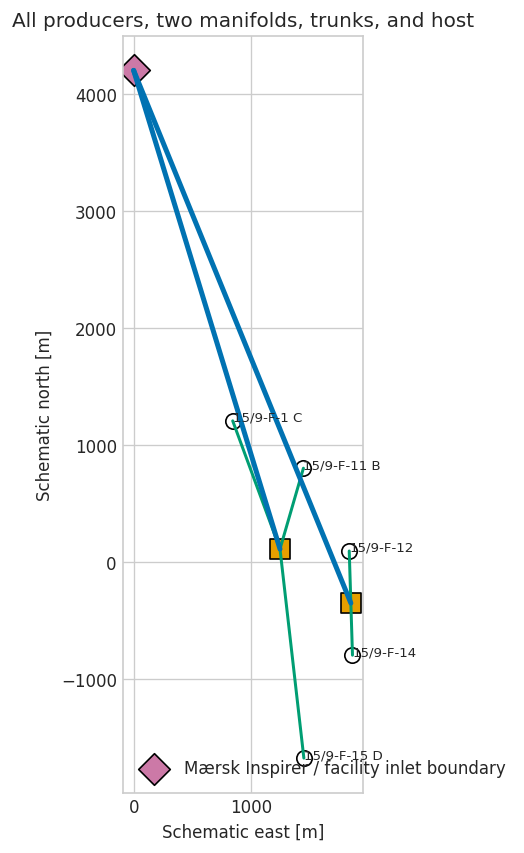

In [7]:
layout_figure, layout_axis = plt.subplots(
    figsize=(9.0, 7.0),
    constrained_layout=True,
)
platform_position = np.array([0.0, 4200.0])
for _, well_row in terminal_geometry.iterrows():
    manifold_row = manifold_geometry.loc[
        manifold_geometry["manifold"].eq(well_row["manifold"])
    ].iloc[0]
    layout_axis.plot(
        [well_row["east_m"], manifold_row["manifold_east_m"]],
        [well_row["north_m"], manifold_row["manifold_north_m"]],
        color="#009E73",
        linewidth=1.8,
    )
    layout_axis.scatter(
        well_row["east_m"],
        well_row["north_m"],
        s=85,
        facecolor="white",
        edgecolor="black",
    )
    layout_axis.text(
        well_row["east_m"],
        well_row["north_m"],
        well_row["well"],
        fontsize=8,
    )
for _, manifold_row in manifold_geometry.iterrows():
    layout_axis.scatter(
        manifold_row["manifold_east_m"],
        manifold_row["manifold_north_m"],
        marker="s",
        s=140,
        color="#E69F00",
        edgecolor="black",
    )
    layout_axis.plot(
        [manifold_row["manifold_east_m"], platform_position[0]],
        [manifold_row["manifold_north_m"], platform_position[1]],
        color="#0072B2",
        linewidth=3.0,
    )
layout_axis.scatter(
    *platform_position,
    marker="D",
    s=180,
    color="#CC79A7",
    edgecolor="black",
    label="Mærsk Inspirer / facility inlet boundary",
)
layout_axis.set(
    xlabel="Schematic east [m]",
    ylabel="Schematic north [m]",
    title="All producers, two manifolds, trunks, and host",
    aspect="equal",
)
layout_axis.legend()
plt.show()


## 3. Production-technology calculation basis

Every well receives an inflow relationship, a multiphase vertical
lift model, a choke loss, and a flowline. The linear IPR screen is

$$q=J(p_r-p_{wf})$$

and the required flowing bottom-hole pressure is

$$p_{wf}^{req}=p_m+\Delta p_{branch}+\Delta p_{choke}+\Delta p_{VLP}$$

The operating point is the IPR/VLP intersection after network
backpressure is included. `PipeBeggsAndBrills` supplies two-rate
hydraulic calibration for each tubing and branch. The reduced
algebraic network then solves quickly across scenarios, and a full
NeqSim `ProcessSystem` verifies the selected coupled point.


In [8]:
SECONDS_PER_DAY = 86400.0
RESERVOIR_TEMPERATURE_C = 97.5
TUBING_DIAMETER_M = 0.140
BRANCH_DIAMETER_M = 0.168
TRUNK_DIAMETER_M = 0.254
RISER_LENGTH_M = 420.0
RISER_ELEVATION_M = 90.0
HOST_PRESSURE_BARA = 20.0
ROUGHNESS_M = 4.5e-5
HEAT_TRANSFER_W_M2_K = 3.0
SEAWATER_TEMPERATURE_C = 6.0


def phase_mass_rate_kg_s(row):
    oil_mass = float(row["oil_rate_Sm3_day"]) * 790.0 / SECONDS_PER_DAY
    gas_mass = float(row["gas_rate_Sm3_day"]) * 0.90 / SECONDS_PER_DAY
    water_mass = float(row["water_rate_Sm3_day"]) * 1000.0 / SECONDS_PER_DAY
    return oil_mass + gas_mass + water_mass


def build_wellstream_fluid(row, total_mass_rate_kg_s, pressure_bara):
    oil_rate = max(float(row["oil_rate_Sm3_day"]), 1.0e-9)
    gas_rate = max(float(row["gas_rate_Sm3_day"]), 1.0e-9)
    water_rate = max(float(row["water_rate_Sm3_day"]), 0.0)
    gor = gas_rate / oil_rate
    water_cut = water_rate / max(oil_rate + water_rate, 1.0e-9)
    gas_fraction = float(np.clip(gor / 360.0, 0.18, 0.68))
    water_fraction = float(np.clip(0.02 + 0.18 * water_cut, 0.02, 0.22))
    heavy_fraction = 1.0 - gas_fraction - water_fraction
    fluid = jneqsim.thermo.system.SystemSrkEos(
        RESERVOIR_TEMPERATURE_C + 273.15,
        pressure_bara,
    )
    fluid.addComponent("methane", 0.72 * gas_fraction)
    fluid.addComponent("ethane", 0.12 * gas_fraction)
    fluid.addComponent("propane", 0.08 * gas_fraction)
    fluid.addComponent("n-heptane", 0.62 * heavy_fraction)
    fluid.addTBPfraction(
        "C10",
        0.38 * heavy_fraction,
        0.200,
        0.82,
    )
    fluid.addComponent("water", water_fraction)
    fluid.setMixingRule("classic")
    fluid.setMultiPhaseCheck(True)
    fluid.setTotalFlowRate(
        max(float(total_mass_rate_kg_s), 1.0e-4),
        "kg/sec",
    )
    TPflash(fluid)
    fluid.initPhysicalProperties()
    return fluid


def run_pipe(
    name,
    inlet_fluid,
    length_m,
    diameter_m,
    elevation_m,
    increments,
):
    inlet_stream = jneqsim.process.equipment.stream.Stream(
        f"{name} inlet",
        inlet_fluid,
    )
    inlet_stream.run()
    pipe = jneqsim.process.equipment.pipeline.PipeBeggsAndBrills(
        name,
        inlet_stream,
    )
    pipe.setLength(float(length_m))
    pipe.setDiameter(float(diameter_m))
    pipe.setElevation(float(elevation_m))
    pipe.setNumberOfIncrements(int(increments))
    pipe.setPipeWallRoughness(ROUGHNESS_M)
    pipe.setConstantSurfaceTemperature(
        SEAWATER_TEMPERATURE_C,
        "C",
    )
    pipe.setHeatTransferCoefficient(HEAT_TRANSFER_W_M2_K)
    pipe.run()
    return pipe


def calibrate_quadratic_pipe(
    name,
    row,
    reference_mass_rate_kg_s,
    inlet_pressure_bara,
    length_m,
    diameter_m,
    elevation_m,
    increments,
):
    rates = [0.55 * reference_mass_rate_kg_s, reference_mass_rate_kg_s]
    pressure_drops = []
    outlet_temperatures = []
    regimes = []
    for rate_index, mass_rate in enumerate(rates):
        fluid = build_wellstream_fluid(row, mass_rate, inlet_pressure_bara)
        pipe = run_pipe(
            f"{name} calibration {rate_index}",
            fluid,
            length_m,
            diameter_m,
            elevation_m,
            increments,
        )
        pressure_drops.append(float(pipe.getPressureDrop()))
        outlet_temperatures.append(
            float(pipe.getOutletStream().getTemperature("C"))
        )
        regimes.append(str(pipe.getFlowRegime()))
    rate_squared = np.square(rates)
    dynamic_coefficient = (
        pressure_drops[1] - pressure_drops[0]
    ) / max(rate_squared[1] - rate_squared[0], 1.0e-12)
    static_pressure = pressure_drops[1] - (
        dynamic_coefficient * rate_squared[1]
    )
    return {
        "static_bar": float(max(static_pressure, 0.0)),
        "dynamic_bar_per_kg_s2": float(
            max(dynamic_coefficient, 1.0e-8)
        ),
        "reference_drop_bar": float(pressure_drops[1]),
        "reference_outlet_temperature_c": float(
            outlet_temperatures[1]
        ),
        "reference_flow_regime": regimes[1],
    }


In [9]:
peak_case = production_cases["peak"].merge(
    terminal_geometry,
    on="well",
    how="left",
)
selected_network_pressure_bara = float(
    reservoir_contract.get("selected_network_pressure_bara", 235.0)
)
calibration_rows = []
for _, well_row in peak_case.iterrows():
    reference_mass_rate = phase_mass_rate_kg_s(well_row)
    tubing_result = calibrate_quadratic_pipe(
        f"{well_row['well']} tubing",
        well_row,
        reference_mass_rate,
        selected_network_pressure_bara,
        well_row["md_m"],
        TUBING_DIAMETER_M,
        well_row["tvd_m"],
        24,
    )
    wellhead_pressure = max(
        selected_network_pressure_bara
        - tubing_result["reference_drop_bar"],
        35.0,
    )
    branch_result = calibrate_quadratic_pipe(
        f"{well_row['well']} branch",
        well_row,
        reference_mass_rate,
        wellhead_pressure,
        well_row["branch_length_m"],
        BRANCH_DIAMETER_M,
        0.0,
        12,
    )
    calibration_rows.append(
        {
            "well": well_row["well"],
            "manifold": well_row["manifold"],
            "reference_mass_rate_kg_s": reference_mass_rate,
            "tubing_static_bar": tubing_result["static_bar"],
            "tubing_k_bar_per_kg_s2": tubing_result[
                "dynamic_bar_per_kg_s2"
            ],
            "branch_static_bar": branch_result["static_bar"],
            "branch_k_bar_per_kg_s2": branch_result[
                "dynamic_bar_per_kg_s2"
            ],
            "reference_wellhead_pressure_bara": wellhead_pressure,
            "branch_outlet_temperature_c": branch_result[
                "reference_outlet_temperature_c"
            ],
            "branch_flow_regime": branch_result[
                "reference_flow_regime"
            ],
        }
    )
hydraulic_calibration = pd.DataFrame(calibration_rows)
display(hydraulic_calibration)
print(
    hydraulic_calibration[
        [
            "well",
            "reference_mass_rate_kg_s",
            "tubing_static_bar",
            "tubing_k_bar_per_kg_s2",
            "branch_k_bar_per_kg_s2",
        ]
    ].to_string(index=False)
)


       well  reference_mass_rate_kg_s  tubing_static_bar  tubing_k_bar_per_kg_s2  branch_k_bar_per_kg_s2
 15/9-F-1 C                  7.986903         211.482846            1.000000e-08                0.006585
15/9-F-11 B                  7.982666         210.591980            1.000000e-08                0.004734
  15/9-F-12                  7.981619         209.000502            1.000000e-08                0.003581
  15/9-F-14                  7.948584         206.176034            1.000000e-08                0.003462
15/9-F-15 D                  7.850954         202.584132            1.000000e-08                0.007975


,well,manifold,reference_mass_rate_kg_s,tubing_static_bar,tubing_k_bar_per_kg_s2,branch_static_bar,branch_k_bar_per_kg_s2,reference_wellhead_pressure_bara,branch_outlet_temperature_c,branch_flow_regime
0,15/9-F-1 C,M1,7.986903,211.482846,1.000000e-08,0.0,0.006585,42.311286,86.801609,INTERMITTENT
1,15/9-F-11 B,M1,7.982666,210.591980,1.000000e-08,0.0,0.004734,43.161714,89.565610,INTERMITTENT
2,15/9-F-12,M2,7.981619,209.000502,1.000000e-08,0.0,0.003581,44.738408,91.290306,INTERMITTENT
3,15/9-F-14,M2,7.948584,206.176034,1.000000e-08,0.0,0.003462,47.547947,91.249110,INTERMITTENT
4,15/9-F-15 D,M1,7.850954,202.584132,1.000000e-08,0.0,0.007975,51.082018,82.661700,INTERMITTENT


## 4. Per-well nodal analysis, choke effects, and lift sensitivity

The nodal solution combines reservoir inflow and the calibrated
tubing/branch pressure requirement at a common manifold pressure.
Choke opening is represented as a bounded quadratic resistance.
A gas-lift sensitivity is included as a production-technology
learning case, not as a claim that the historical Volve wells used
that lift method.

The selected operating point is stable only if additional rate
lowers the IPR pressure and raises the VLP requirement. Final well
design still needs completion, skin, inflow-transient, lift, sand,
scale, integrity, and calibrated well-model evidence.


In [10]:
peak_case = peak_case.merge(
    hydraulic_calibration,
    on=["well", "manifold"],
    how="left",
)
average_reference_mass = peak_case[
    "reference_mass_rate_kg_s"
].mean()
peak_case["productivity_kg_s_bar"] = (
    peak_case["reference_mass_rate_kg_s"]
    / 42.0
    * peak_case["productivity_factor"]
)
peak_case["choke_k_bar_per_kg_s2"] = (
    0.020 / np.square(np.clip(peak_case["productivity_factor"], 0.5, 2.0))
)


def nodal_pressures(well_row, mass_rate_kg_s, manifold_pressure_bara):
    productivity = max(
        float(well_row["productivity_kg_s_bar"]),
        1.0e-5,
    )
    ipr_pressure = selected_network_pressure_bara - (
        mass_rate_kg_s / productivity
    )
    static_pressure = (
        float(well_row["tubing_static_bar"])
        + float(well_row["branch_static_bar"])
    )
    dynamic_coefficient = (
        float(well_row["tubing_k_bar_per_kg_s2"])
        + float(well_row["branch_k_bar_per_kg_s2"])
        + float(well_row["choke_k_bar_per_kg_s2"])
    )
    required_pressure = (
        manifold_pressure_bara
        + static_pressure
        + dynamic_coefficient * mass_rate_kg_s**2
    )
    return ipr_pressure, required_pressure


manifold_screen_pressure_bara = 30.0
nodal_rows = []
nodal_curves = {}
for _, well_row in peak_case.iterrows():
    maximum_rate = max(
        2.0 * float(well_row["reference_mass_rate_kg_s"]),
        average_reference_mass,
    )
    def pressure_mismatch(mass_rate):
        pressures = nodal_pressures(
            well_row,
            mass_rate,
            manifold_screen_pressure_bara,
        )
        return pressures[0] - pressures[1]

    while pressure_mismatch(maximum_rate) > 0.0:
        maximum_rate *= 1.5
        if maximum_rate > 12.0 * max(
            float(well_row["reference_mass_rate_kg_s"]),
            1.0,
        ):
            break
    rate_grid = np.linspace(0.0, maximum_rate, 120)
    ipr_values = []
    vlp_values = []
    for mass_rate in rate_grid:
        ipr_pressure, required_pressure = nodal_pressures(
            well_row,
            mass_rate,
            manifold_screen_pressure_bara,
        )
        ipr_values.append(ipr_pressure)
        vlp_values.append(required_pressure)
    if pressure_mismatch(0.0) <= 0.0:
        raise RuntimeError(
            f"No positive drawdown for {well_row['well']}."
        )
    if pressure_mismatch(maximum_rate) >= 0.0:
        raise RuntimeError(
            f"Nodal upper bound is too low for {well_row['well']}."
        )
    operating_rate = brentq(
        pressure_mismatch,
        0.0,
        maximum_rate,
    )
    operating_pressure = nodal_pressures(
        well_row,
        operating_rate,
        manifold_screen_pressure_bara,
    )[0]
    nodal_curves[well_row["well"]] = {
        "rate": rate_grid,
        "ipr": np.asarray(ipr_values),
        "vlp": np.asarray(vlp_values),
    }
    nodal_rows.append(
        {
            "well": well_row["well"],
            "operating_mass_rate_kg_s": operating_rate,
            "operating_bhp_bara": operating_pressure,
            "manifold_pressure_bara": manifold_screen_pressure_bara,
            "reference_mass_rate_kg_s": well_row[
                "reference_mass_rate_kg_s"
            ],
        }
    )
nodal_table = pd.DataFrame(nodal_rows)
display(nodal_table)


,well,operating_mass_rate_kg_s,operating_bhp_bara,manifold_pressure_bara,reference_mass_rate_kg_s
0,15/9-F-1 C,2.130820,241.569298,30.0,7.986903
1,15/9-F-11 B,2.033438,240.679981,30.0,7.982666
2,15/9-F-12,1.994262,239.107054,30.0,7.981619
3,15/9-F-14,2.286177,236.336057,30.0,7.948584
4,15/9-F-15 D,2.778807,232.860981,30.0,7.850954


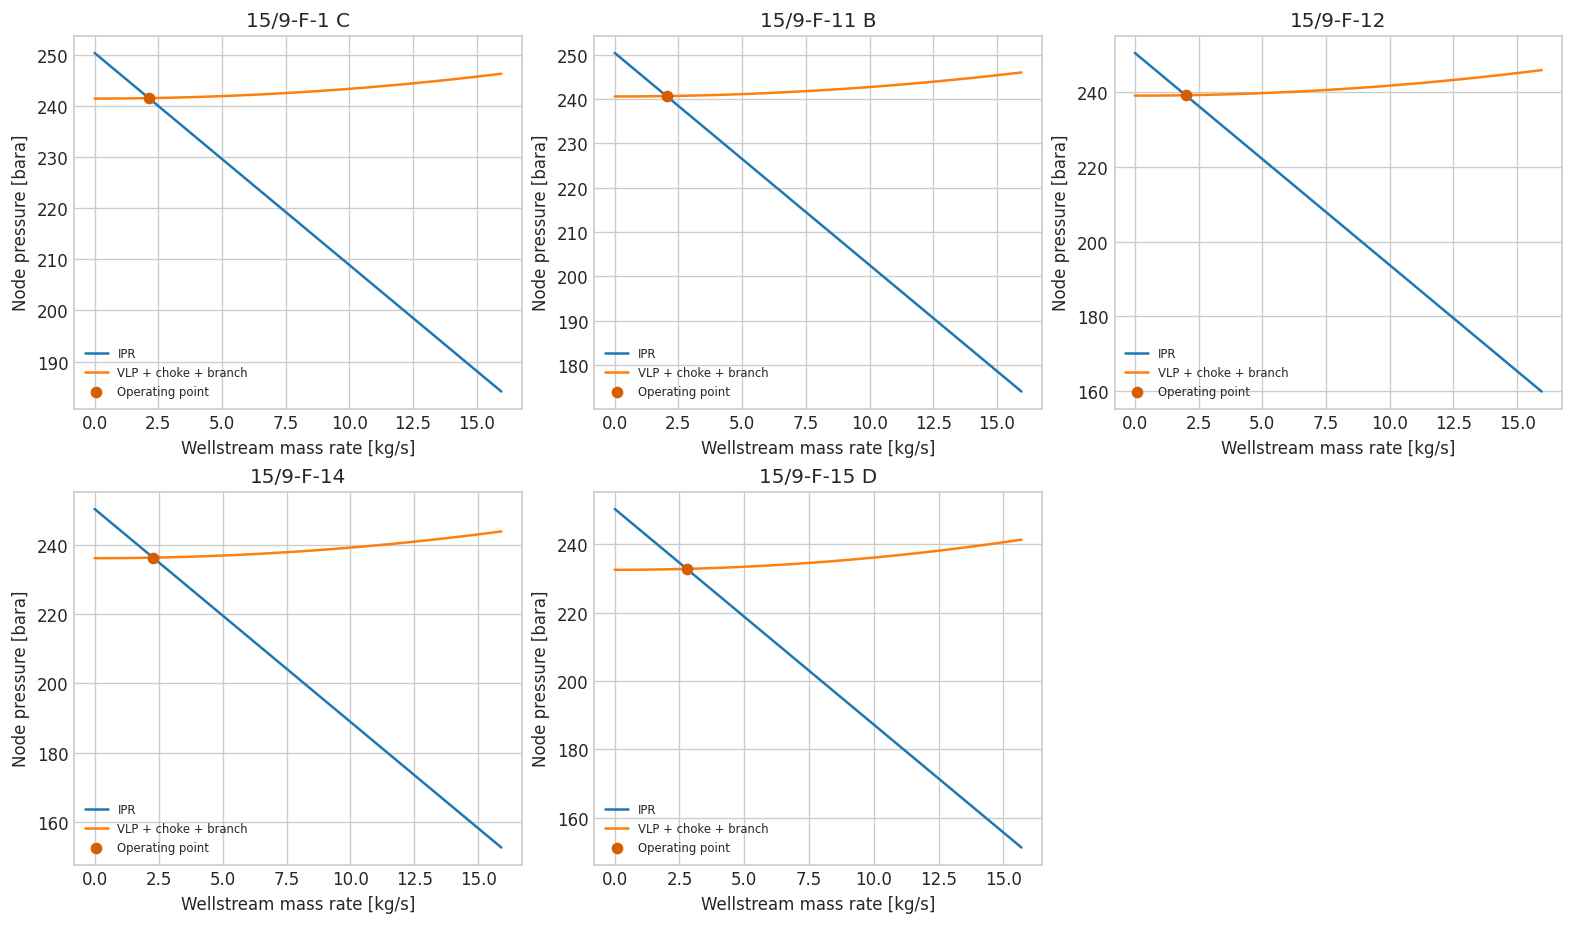

In [11]:
well_count = len(nodal_curves)
column_count = 3
row_count = int(math.ceil(well_count / column_count))
nodal_figure, nodal_axes = plt.subplots(
    row_count,
    column_count,
    figsize=(13.0, 3.8 * row_count),
    constrained_layout=True,
)
axes_flat = np.atleast_1d(nodal_axes).ravel()
for axis, (well_name, curve) in zip(axes_flat, nodal_curves.items()):
    operating = nodal_table.loc[nodal_table["well"].eq(well_name)].iloc[0]
    axis.plot(curve["rate"], curve["ipr"], label="IPR")
    axis.plot(curve["rate"], curve["vlp"], label="VLP + choke + branch")
    axis.scatter(
        operating["operating_mass_rate_kg_s"],
        operating["operating_bhp_bara"],
        color="#D55E00",
        zorder=4,
        label="Operating point",
    )
    axis.set(
        xlabel="Wellstream mass rate [kg/s]",
        ylabel="Node pressure [bara]",
        title=well_name,
    )
    axis.legend(fontsize=7)
for axis in axes_flat[well_count:]:
    axis.set_visible(False)
plt.show()


In [12]:
lift_rows = []
representative_well = peak_case.sort_values(
    "reference_mass_rate_kg_s",
    ascending=False,
).iloc[0]
for gas_lift_rate_sm3_day in [0.0, 25000.0, 50000.0, 75000.0, 100000.0]:
    lift_pressure_reduction = min(
        14.0,
        0.00012 * gas_lift_rate_sm3_day,
    )
    adjusted_row = representative_well.copy()
    adjusted_row["tubing_static_bar"] = max(
        float(representative_well["tubing_static_bar"])
        - lift_pressure_reduction,
        0.0,
    )
    maximum_rate = 2.4 * representative_well[
        "reference_mass_rate_kg_s"
    ]
    def lift_mismatch(rate):
        pressures = nodal_pressures(
            adjusted_row,
            rate,
            manifold_screen_pressure_bara,
        )
        return pressures[0] - pressures[1]

    while lift_mismatch(maximum_rate) > 0.0:
        maximum_rate *= 1.5
        if maximum_rate > 12.0 * max(
            representative_well["reference_mass_rate_kg_s"],
            1.0,
        ):
            break
    operating_rate = np.nan
    if lift_mismatch(0.0) > 0.0 and lift_mismatch(maximum_rate) < 0.0:
        operating_rate = brentq(
            lift_mismatch,
            0.0,
            maximum_rate,
        )
    lift_rows.append(
        {
            "well": representative_well["well"],
            "gas_lift_rate_Sm3_day": gas_lift_rate_sm3_day,
            "screened_mass_rate_kg_s": operating_rate,
            "tubing_static_reduction_bar": lift_pressure_reduction,
        }
    )
lift_screen = pd.DataFrame(lift_rows)
display(lift_screen)


,well,gas_lift_rate_Sm3_day,screened_mass_rate_kg_s,tubing_static_reduction_bar
0,15/9-F-1 C,0.0,2.130820,0.0
1,15/9-F-1 C,25000.0,2.837622,3.0
2,15/9-F-1 C,50000.0,3.539983,6.0
3,15/9-F-1 C,75000.0,4.237988,9.0
4,15/9-F-1 C,100000.0,4.931715,12.0


## 5. Coupled two-manifold network solution

The fast network uses NeqSim-calibrated segment equations. For well
$w$ connected to manifold $m$,

$$p_m=p_r-p_{static,w}-\frac{\dot m_w}{PI_w}-K_w\dot m_w^2$$

Each manifold pressure is solved so its trunk reaches the common
riser-base pressure. The riser-base pressure is then solved so the
riser reaches the specified facility inlet. All wells therefore
react to common backpressure and to one another; rates are not
summed after independent calculations.


In [13]:
def aggregate_case_row(case):
    totals = case[
        [
            "oil_rate_Sm3_day",
            "gas_rate_Sm3_day",
            "water_rate_Sm3_day",
        ]
    ].sum()
    return totals.to_dict()


trunk_rows = []
for manifold_name, manifold_wells in peak_case.groupby("manifold"):
    aggregate_row = aggregate_case_row(manifold_wells)
    reference_mass = phase_mass_rate_kg_s(aggregate_row)
    trunk_result = calibrate_quadratic_pipe(
        f"{manifold_name} trunk",
        aggregate_row,
        reference_mass,
        65.0,
        6500.0 if manifold_name == "M1" else 7200.0,
        TRUNK_DIAMETER_M,
        0.0,
        20,
    )
    trunk_rows.append(
        {
            "manifold": manifold_name,
            "trunk_static_bar": trunk_result["static_bar"],
            "trunk_k_bar_per_kg_s2": trunk_result[
                "dynamic_bar_per_kg_s2"
            ],
            "trunk_reference_drop_bar": trunk_result[
                "reference_drop_bar"
            ],
            "trunk_reference_temperature_c": trunk_result[
                "reference_outlet_temperature_c"
            ],
            "trunk_flow_regime": trunk_result[
                "reference_flow_regime"
            ],
        }
    )
trunk_calibration = pd.DataFrame(trunk_rows)

aggregate_peak = aggregate_case_row(peak_case)
peak_total_mass = phase_mass_rate_kg_s(aggregate_peak)
riser_calibration = calibrate_quadratic_pipe(
    "common riser",
    aggregate_peak,
    peak_total_mass,
    45.0,
    RISER_LENGTH_M,
    TRUNK_DIAMETER_M,
    RISER_ELEVATION_M,
    18,
)
display(trunk_calibration)
display(pd.DataFrame([riser_calibration]))


,manifold,trunk_static_bar,trunk_k_bar_per_kg_s2,trunk_reference_drop_bar,trunk_reference_temperature_c,trunk_flow_regime
0,M1,0.0,0.002142,1.114991,77.076807,INTERMITTENT
1,M2,0.0,0.002164,0.545962,65.809691,TRANSITION


,static_bar,dynamic_bar_per_kg_s2,reference_drop_bar,reference_outlet_temperature_c,reference_flow_regime
0,3.818879,0.000098,3.973907,96.452449,INTERMITTENT


In [14]:
hydraulic_by_well = peak_case.set_index("well")
trunk_by_manifold = trunk_calibration.set_index("manifold")


def well_rate_for_manifold(
    well_row,
    reservoir_pressure_bara,
    manifold_pressure_bara,
    productivity_multiplier=1.0,
):
    productivity = max(
        float(well_row["productivity_kg_s_bar"])
        * productivity_multiplier,
        1.0e-8,
    )
    static_pressure = (
        float(well_row["tubing_static_bar"])
        + float(well_row["branch_static_bar"])
    )
    dynamic_coefficient = (
        float(well_row["tubing_k_bar_per_kg_s2"])
        + float(well_row["branch_k_bar_per_kg_s2"])
        + float(well_row["choke_k_bar_per_kg_s2"])
    )
    available_pressure = (
        reservoir_pressure_bara
        - static_pressure
        - manifold_pressure_bara
    )
    if available_pressure <= 0.0:
        return 0.0
    linear_coefficient = 1.0 / productivity
    discriminant = linear_coefficient**2 + (
        4.0 * dynamic_coefficient * available_pressure
    )
    return (
        -linear_coefficient + math.sqrt(discriminant)
    ) / (2.0 * dynamic_coefficient)


def solve_manifold(
    manifold_name,
    base_pressure_bara,
    reservoir_pressure_bara,
    productivity_multipliers,
):
    wells = hydraulic_by_well.loc[
        hydraulic_by_well["manifold"].eq(manifold_name)
    ]
    trunk = trunk_by_manifold.loc[manifold_name]

    def trunk_residual(manifold_pressure_bara):
        rates = [
            well_rate_for_manifold(
                well_row,
                reservoir_pressure_bara,
                manifold_pressure_bara,
                productivity_multipliers.get(well_name, 1.0),
            )
            for well_name, well_row in wells.iterrows()
        ]
        total_rate = sum(rates)
        required_base = (
            manifold_pressure_bara
            - float(trunk["trunk_static_bar"])
            - float(trunk["trunk_k_bar_per_kg_s2"])
            * total_rate**2
        )
        return required_base - base_pressure_bara

    lower_pressure = base_pressure_bara
    upper_pressure = max(
        reservoir_pressure_bara
        - float(wells["tubing_static_bar"].min())
        - 0.1,
        lower_pressure + 0.2,
    )
    if trunk_residual(lower_pressure) * trunk_residual(upper_pressure) > 0.0:
        manifold_pressure = lower_pressure
    else:
        manifold_pressure = brentq(
            trunk_residual,
            lower_pressure,
            upper_pressure,
        )
    well_rates = {
        well_name: well_rate_for_manifold(
            well_row,
            reservoir_pressure_bara,
            manifold_pressure,
            productivity_multipliers.get(well_name, 1.0),
        )
        for well_name, well_row in wells.iterrows()
    }
    return manifold_pressure, well_rates


def solve_network(
    case_name,
    reservoir_pressure_bara,
    productivity_multipliers,
    host_pressure_bara=HOST_PRESSURE_BARA,
):
    riser_static = float(riser_calibration["static_bar"])
    riser_dynamic = float(
        riser_calibration["dynamic_bar_per_kg_s2"]
    )

    def host_residual(base_pressure_bara):
        all_rates = {}
        manifold_pressures = {}
        for manifold_name in trunk_by_manifold.index:
            manifold_pressure, manifold_rates = solve_manifold(
                manifold_name,
                base_pressure_bara,
                reservoir_pressure_bara,
                productivity_multipliers,
            )
            manifold_pressures[manifold_name] = manifold_pressure
            all_rates.update(manifold_rates)
        total_rate = sum(all_rates.values())
        predicted_host_pressure = (
            base_pressure_bara
            - riser_static
            - riser_dynamic * total_rate**2
        )
        return (
            predicted_host_pressure - host_pressure_bara,
            manifold_pressures,
            all_rates,
        )

    minimum_base_pressure = host_pressure_bara + riser_static
    maximum_base_pressure = max(
        reservoir_pressure_bara
        - float(hydraulic_by_well["tubing_static_bar"].min())
        - 1.0,
        minimum_base_pressure + 1.0,
    )
    base_pressure = brentq(
        lambda pressure: host_residual(pressure)[0],
        minimum_base_pressure,
        maximum_base_pressure,
    )
    residual, manifold_pressures, well_rates = host_residual(
        base_pressure
    )
    return {
        "case": case_name,
        "reservoir_pressure_bara": reservoir_pressure_bara,
        "riser_base_pressure_bara": base_pressure,
        "host_pressure_bara": host_pressure_bara + residual,
        "manifold_pressures_bara": manifold_pressures,
        "well_mass_rates_kg_s": well_rates,
        "total_mass_rate_kg_s": sum(well_rates.values()),
    }


In [15]:
terminal_pressure = float(reservoir_contract["terminal_pressure_bara"])
largest_well = peak_case.sort_values(
    "reference_mass_rate_kg_s",
    ascending=False,
).iloc[0]["well"]
base_multipliers = {
    well_name: 1.0 for well_name in hydraulic_by_well.index
}
scenario_definitions = [
    (
        "peak",
        selected_network_pressure_bara,
        base_multipliers,
    ),
    (
        "mature",
        0.5 * (selected_network_pressure_bara + terminal_pressure),
        {well_name: 0.82 for well_name in hydraulic_by_well.index},
    ),
    (
        "late life",
        terminal_pressure,
        {well_name: 0.62 for well_name in hydraulic_by_well.index},
    ),
    (
        "largest well outage",
        0.5 * (selected_network_pressure_bara + terminal_pressure),
        {
            well_name: (0.0 if well_name == largest_well else 0.82)
            for well_name in hydraulic_by_well.index
        },
    ),
    (
        "turndown",
        terminal_pressure,
        {well_name: 0.30 for well_name in hydraulic_by_well.index},
    ),
]
network_solutions = [
    solve_network(case_name, reservoir_pressure, multipliers)
    for case_name, reservoir_pressure, multipliers in scenario_definitions
]
network_summary = pd.DataFrame(
    [
        {
            "case": solution["case"],
            "reservoir pressure [bara]": solution[
                "reservoir_pressure_bara"
            ],
            "M1 pressure [bara]": solution[
                "manifold_pressures_bara"
            ].get("M1", np.nan),
            "M2 pressure [bara]": solution[
                "manifold_pressures_bara"
            ].get("M2", np.nan),
            "riser-base pressure [bara]": solution[
                "riser_base_pressure_bara"
            ],
            "host pressure [bara]": solution["host_pressure_bara"],
            "total mass rate [kg/s]": solution[
                "total_mass_rate_kg_s"
            ],
            "active wells": sum(
                rate > 1.0e-5
                for rate in solution["well_mass_rates_kg_s"].values()
            ),
        }
        for solution in network_solutions
    ]
)
display(network_summary)


,case,reservoir pressure [bara],M1 pressure [bara],M2 pressure [bara],riser-base pressure [bara],host pressure [bara],total mass rate [kg/s],active wells
0,peak,250.411928,24.080061,23.931828,23.846345,20.0,16.731485,5
1,mature,232.955359,23.820572,23.819404,23.819035,20.0,1.260296,3
2,late life,215.498790,23.818879,23.818879,23.818879,20.0,0.000000,0
3,largest well outage,232.955359,23.820572,23.819404,23.819035,20.0,1.260296,3
4,turndown,215.498790,23.818879,23.818879,23.818879,20.0,0.000000,0


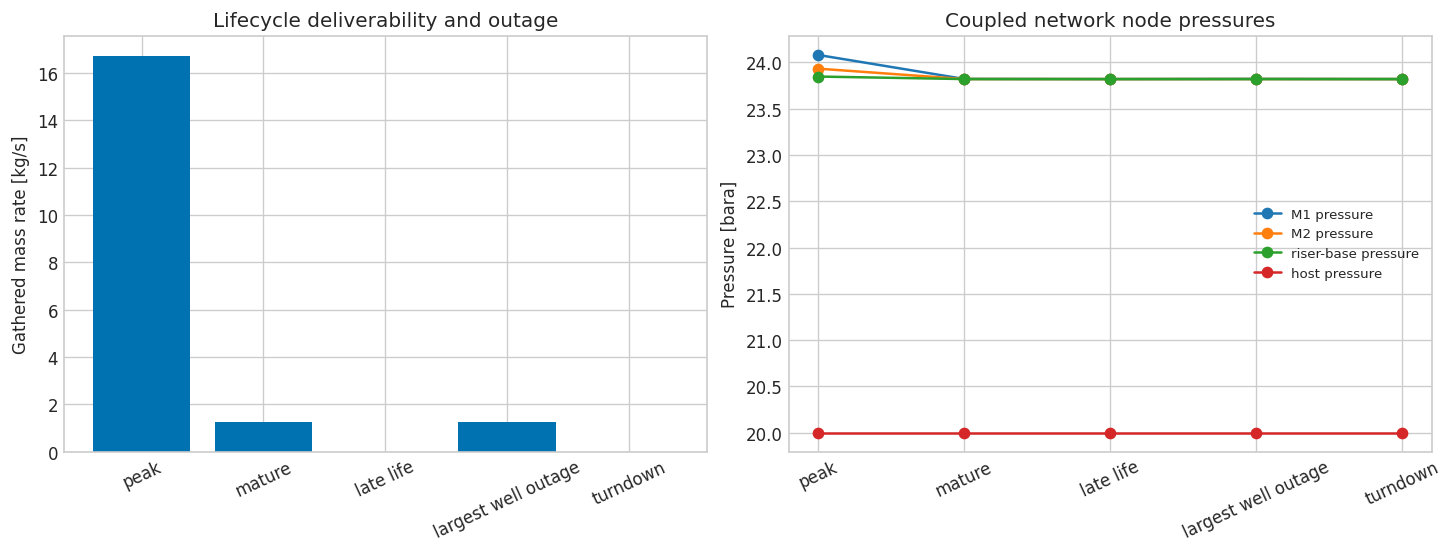

In [16]:
scenario_figure, scenario_axes = plt.subplots(
    1,
    2,
    figsize=(12.0, 4.5),
    constrained_layout=True,
)
scenario_axes[0].bar(
    network_summary["case"],
    network_summary["total mass rate [kg/s]"],
    color="#0072B2",
)
scenario_axes[0].set(
    ylabel="Gathered mass rate [kg/s]",
    title="Lifecycle deliverability and outage",
)
scenario_axes[0].tick_params(axis="x", rotation=25)
pressure_columns = [
    "M1 pressure [bara]",
    "M2 pressure [bara]",
    "riser-base pressure [bara]",
    "host pressure [bara]",
]
for pressure_column in pressure_columns:
    scenario_axes[1].plot(
        network_summary["case"],
        network_summary[pressure_column],
        marker="o",
        label=pressure_column.replace(" [bara]", ""),
    )
scenario_axes[1].set(
    ylabel="Pressure [bara]",
    title="Coupled network node pressures",
)
scenario_axes[1].tick_params(axis="x", rotation=25)
scenario_axes[1].legend(fontsize=8)
plt.show()


## 6. Full NeqSim ProcessSystem verification

The algebraic solve is checked at the peak point with an explicit,
composable NeqSim process: one stream, tubing, and branch per well;
two manifold mixers; two trunks; a central mixer; and one riser.
Every producer remains visible as a named object. The verification
retains pressure and temperature profiles, flow regimes, holdup,
velocity, erosion velocity, and FIV indicators.

A steady Beggs–Brill network is appropriate for screening. Terrain
slugging, severe slugging, dynamic choking, restart fronts, and
coupled reservoir-network transients require a specialist transient
multiphase model and operating validation.


In [17]:
selected_solution = network_solutions[0]
network_process = jneqsim.process.processmodel.ProcessSystem()
branch_pipes = {}
tubing_pipes = {}
choke_valves = {}
manifold_mixers = {}
trunk_pipes = {}

for manifold_name in trunk_by_manifold.index:
    manifold_mixers[manifold_name] = (
        jneqsim.process.equipment.mixer.Mixer(
            f"{manifold_name} gathering manifold"
        )
    )

for well_name, solved_mass_rate in selected_solution[
    "well_mass_rates_kg_s"
].items():
    well_row = hydraulic_by_well.loc[well_name]
    productivity_kg_s_bar = max(
        float(well_row["productivity_kg_s_bar"]),
        1.0e-8,
    )
    flowing_bottomhole_pressure_bara = (
        selected_solution["reservoir_pressure_bara"]
        - solved_mass_rate / productivity_kg_s_bar
    )
    reservoir_fluid = build_wellstream_fluid(
        well_row,
        solved_mass_rate,
        flowing_bottomhole_pressure_bara,
    )
    reservoir_stream = jneqsim.process.equipment.stream.Stream(
        f"{well_name} reservoir node",
        reservoir_fluid,
    )
    tubing = jneqsim.process.equipment.pipeline.PipeBeggsAndBrills(
        f"{well_name} tubing",
        reservoir_stream,
    )
    tubing.setLength(float(well_row["md_m"]))
    tubing.setDiameter(TUBING_DIAMETER_M)
    tubing.setElevation(float(well_row["tvd_m"]))
    tubing.setNumberOfIncrements(24)
    tubing.setPipeWallRoughness(ROUGHNESS_M)
    tubing.setConstantSurfaceTemperature(65.0, "C")
    tubing.setHeatTransferCoefficient(2.0)
    branch = jneqsim.process.equipment.pipeline.PipeBeggsAndBrills(
        f"{well_name} branch",
        tubing.getOutletStream(),
    )
    branch.setLength(float(well_row["branch_length_m"]))
    branch.setDiameter(BRANCH_DIAMETER_M)
    branch.setElevation(0.0)
    branch.setNumberOfIncrements(12)
    branch.setPipeWallRoughness(ROUGHNESS_M)
    branch.setConstantSurfaceTemperature(
        SEAWATER_TEMPERATURE_C,
        "C",
    )
    branch.setHeatTransferCoefficient(HEAT_TRANSFER_W_M2_K)
    choke = jneqsim.process.equipment.valve.ThrottlingValve(
        f"{well_name} manifold pressure-control choke",
        branch.getOutletStream(),
    )
    choke.setOutletPressure(
        selected_solution["manifold_pressures_bara"][
            well_row["manifold"]
        ],
        "bara",
    )
    network_process.add(reservoir_stream)
    network_process.add(tubing)
    network_process.add(branch)
    network_process.add(choke)
    manifold_mixers[well_row["manifold"]].addStream(
        choke.getOutletStream()
    )
    tubing_pipes[well_name] = tubing
    branch_pipes[well_name] = branch
    choke_valves[well_name] = choke

central_mixer = jneqsim.process.equipment.mixer.Mixer(
    "central riser-base mixer"
)
for manifold_name, manifold_mixer in manifold_mixers.items():
    network_process.add(manifold_mixer)
    trunk = jneqsim.process.equipment.pipeline.PipeBeggsAndBrills(
        f"{manifold_name} trunk",
        manifold_mixer.getOutletStream(),
    )
    trunk.setLength(6500.0 if manifold_name == "M1" else 7200.0)
    trunk.setDiameter(TRUNK_DIAMETER_M)
    trunk.setElevation(0.0)
    trunk.setNumberOfIncrements(20)
    trunk.setPipeWallRoughness(ROUGHNESS_M)
    trunk.setConstantSurfaceTemperature(
        SEAWATER_TEMPERATURE_C,
        "C",
    )
    trunk.setHeatTransferCoefficient(HEAT_TRANSFER_W_M2_K)
    network_process.add(trunk)
    central_mixer.addStream(trunk.getOutletStream())
    trunk_pipes[manifold_name] = trunk
network_process.add(central_mixer)
riser = jneqsim.process.equipment.pipeline.PipeBeggsAndBrills(
    "common production riser",
    central_mixer.getOutletStream(),
)
riser.setLength(RISER_LENGTH_M)
riser.setDiameter(TRUNK_DIAMETER_M)
riser.setElevation(RISER_ELEVATION_M)
riser.setNumberOfIncrements(18)
riser.setPipeWallRoughness(ROUGHNESS_M)
riser.setConstantSurfaceTemperature(SEAWATER_TEMPERATURE_C, "C")
riser.setHeatTransferCoefficient(HEAT_TRANSFER_W_M2_K)
network_process.add(riser)
network_process.run()

direct_host_pressure_bara = float(
    riser.getOutletStream().getPressure("bara")
)
direct_host_temperature_c = float(
    riser.getOutletStream().getTemperature("C")
)
direct_total_mass_rate_kg_s = float(
    riser.getOutletStream().getFlowRate("kg/sec")
)
average_choke_drop_bar = float(
    np.mean(
        [
            branch_pipes[well_name].getOutletStream().getPressure(
                "bara"
            )
            - choke_valve.getOutletStream().getPressure("bara")
            for well_name, choke_valve in choke_valves.items()
        ]
    )
)
process_summary = pd.DataFrame(
    {
        "quantity": [
            "algebraic gathered mass rate",
            "direct NeqSim gathered mass rate",
            "specified host pressure",
            "direct NeqSim host pressure",
            "direct NeqSim host temperature",
            "average choke pressure drop",
        ],
        "value": [
            selected_solution["total_mass_rate_kg_s"],
            direct_total_mass_rate_kg_s,
            HOST_PRESSURE_BARA,
            direct_host_pressure_bara,
            direct_host_temperature_c,
            average_choke_drop_bar,
        ],
        "unit": ["kg/s", "kg/s", "bara", "bara", "°C", "bar"],
    }
)
display(process_summary)


,quantity,value,unit
0,algebraic gathered mass rate,16.731485,kg/s
1,direct NeqSim gathered mass rate,16.731485,kg/s
2,specified host pressure,20.000000,bara
3,direct NeqSim host pressure,20.354294,bara
4,direct NeqSim host temperature,33.497622,°C
5,average choke pressure drop,10.915203,bar


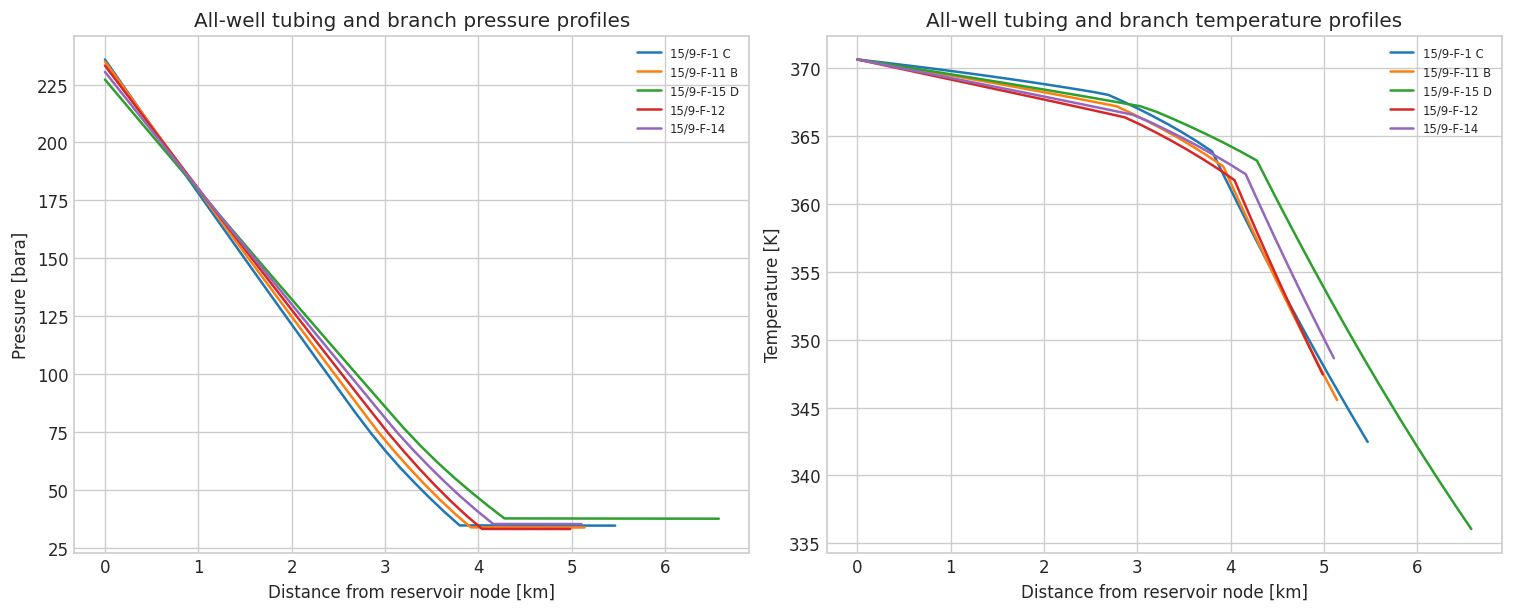

In [18]:
profile_figure, profile_axes = plt.subplots(
    1,
    2,
    figsize=(12.5, 5.0),
    constrained_layout=True,
)
for well_name in tubing_pipes:
    tubing = tubing_pipes[well_name]
    branch = branch_pipes[well_name]
    tubing_distance = np.linspace(
        0.0,
        float(hydraulic_by_well.loc[well_name, "md_m"]),
        len(tubing.getPressureProfile()),
    )
    branch_length = float(
        hydraulic_by_well.loc[well_name, "branch_length_m"]
    )
    branch_distance = tubing_distance[-1] + np.linspace(
        0.0,
        branch_length,
        len(branch.getPressureProfile()),
    )
    distance = np.concatenate([tubing_distance, branch_distance[1:]])
    pressure = np.concatenate(
        [
            np.asarray(tubing.getPressureProfile(), dtype=float),
            np.asarray(branch.getPressureProfile(), dtype=float)[1:],
        ]
    )
    temperature = np.concatenate(
        [
            np.asarray(tubing.getTemperatureProfile(), dtype=float),
            np.asarray(branch.getTemperatureProfile(), dtype=float)[1:],
        ]
    )
    profile_axes[0].plot(distance / 1000.0, pressure, label=well_name)
    profile_axes[1].plot(
        distance / 1000.0,
        temperature,
        label=well_name,
    )
profile_axes[0].set(
    xlabel="Distance from reservoir node [km]",
    ylabel="Pressure [bara]",
    title="All-well tubing and branch pressure profiles",
)
profile_axes[1].set(
    xlabel="Distance from reservoir node [km]",
    ylabel="Temperature [K]",
    title="All-well tubing and branch temperature profiles",
)
for axis in profile_axes:
    axis.legend(fontsize=7)
plt.show()


In [19]:
integrity_rows = []
for well_name, branch in branch_pipes.items():
    holdup_profile = np.asarray(
        branch.getLiquidHoldupProfile(),
        dtype=float,
    )
    integrity_rows.append(
        {
            "well": well_name,
            "flow_regime": str(branch.getFlowRegime()),
            "mixture_velocity_m_s": float(branch.getMixtureVelocity()),
            "average_liquid_holdup": float(
                np.nanmean(holdup_profile)
            ),
            "erosional_velocity_m_s": float(
                branch.getErosionalVelocity()
            ),
            "FIV_LOF": float(branch.calculateLOF()),
            "FIV_force_N_m": float(branch.calculateFRMS()),
            "branch_pressure_drop_bar": float(
                branch.getPressureDrop()
            ),
        }
    )
integrity_screen = pd.DataFrame(integrity_rows)
integrity_screen["velocity_margin_m_s"] = (
    integrity_screen["erosional_velocity_m_s"]
    - integrity_screen["mixture_velocity_m_s"]
)
display(integrity_screen)


,well,flow_regime,mixture_velocity_m_s,average_liquid_holdup,erosional_velocity_m_s,FIV_LOF,FIV_force_N_m,branch_pressure_drop_bar,velocity_margin_m_s
0,15/9-F-1 C,TRANSITION,0.447417,0.715322,4.397265,0.004677,1.113261,0.085085,3.949848
1,15/9-F-11 B,TRANSITION,0.424094,0.728625,4.377156,0.004241,1.042251,0.055489,3.953062
2,15/9-F-15 D,TRANSITION,0.416819,0.756840,4.257401,0.004330,1.024678,0.116679,3.840582
3,15/9-F-12,TRANSITION,0.406228,0.738281,4.361746,0.003919,0.988825,0.038870,3.955519
4,15/9-F-14,TRANSITION,0.411224,0.749928,4.338314,0.004059,1.001176,0.041622,3.927090


## 7. Operations, shutdown, cooldown, and restart

Operations decisions change across field life. Peak production is
capacity-limited; mature production emphasizes allocation and
water handling; late life emphasizes turndown, stability, integrity,
and intervention value. A well outage redistributes network
backpressure and tests whether spare capacity is usable.

During shutdown, advection disappears while pressure and liquid
inventory remain. The lumped cooldown screen estimates time to a
conservative hydrate boundary. Restart is evaluated as a staged
rate ramp with required riser-base pressure. These calculations
define an operating window, not a transient operating procedure.


In [20]:
pipeline_segments = []
for well_name, branch in branch_pipes.items():
    pipeline_segments.append(
        {
            "segment": f"{well_name} branch",
            "length_m": float(
                hydraulic_by_well.loc[well_name, "branch_length_m"]
            ),
            "diameter_m": BRANCH_DIAMETER_M,
            "holdup": float(
                np.nanmean(
                    np.asarray(
                        branch.getLiquidHoldupProfile(),
                        dtype=float,
                    )
                )
            ),
        }
    )
for manifold_name, trunk in trunk_pipes.items():
    pipeline_segments.append(
        {
            "segment": f"{manifold_name} trunk",
            "length_m": (
                6500.0 if manifold_name == "M1" else 7200.0
            ),
            "diameter_m": TRUNK_DIAMETER_M,
            "holdup": float(
                np.nanmean(
                    np.asarray(
                        trunk.getLiquidHoldupProfile(),
                        dtype=float,
                    )
                )
            ),
        }
    )
pipeline_segments.append(
    {
        "segment": "common riser",
        "length_m": RISER_LENGTH_M,
        "diameter_m": TRUNK_DIAMETER_M,
        "holdup": float(
            np.nanmean(
                np.asarray(riser.getLiquidHoldupProfile(), dtype=float)
            )
        ),
    }
)
inventory_table = pd.DataFrame(pipeline_segments)
inventory_table["internal_volume_m3"] = (
    math.pi
    * np.square(inventory_table["diameter_m"])
    / 4.0
    * inventory_table["length_m"]
)
inventory_table["screened_liquid_inventory_m3"] = (
    inventory_table["internal_volume_m3"]
    * inventory_table["holdup"].clip(0.0, 1.0)
)
display(inventory_table)

shutdown_pressure_bara = direct_host_pressure_bara
shutdown_temperature_c = direct_host_temperature_c
hydrate_boundary_c = 15.0 + 0.055 * shutdown_pressure_bara
thermal_time_constant_h = 18.0
shutdown_hours = np.linspace(0.0, 72.0, 145)
cooldown_temperature_c = SEAWATER_TEMPERATURE_C + (
    shutdown_temperature_c - SEAWATER_TEMPERATURE_C
) * np.exp(-shutdown_hours / thermal_time_constant_h)
hydrate_crossing = np.flatnonzero(
    cooldown_temperature_c <= hydrate_boundary_c
)
time_to_hydrate_boundary_h = (
    float(shutdown_hours[hydrate_crossing[0]])
    if len(hydrate_crossing)
    else float("inf")
)
print(
    {
        "screened liquid inventory m3": float(
            inventory_table["screened_liquid_inventory_m3"].sum()
        ),
        "hydrate boundary C": hydrate_boundary_c,
        "time to hydrate boundary h": time_to_hydrate_boundary_h,
    }
)


{'screened liquid inventory m3': 588.268246817812, 'hydrate boundary C': 16.119486190842093, 'time to hydrate boundary h': 18.0}


,segment,length_m,diameter_m,holdup,internal_volume_m3,screened_liquid_inventory_m3
0,15/9-F-1 C branch,1666.857013,0.168,0.715322,36.949349,26.430667
1,15/9-F-11 B branch,1218.852240,0.168,0.728625,27.018392,19.686268
2,15/9-F-15 D branch,2296.776106,0.168,0.756840,50.912815,38.532836
3,15/9-F-12 branch,945.026984,0.168,0.738281,20.948487,15.465879
4,15/9-F-14 branch,945.026984,0.168,0.749928,20.948487,15.709851
5,M1 trunk,6500.000000,0.254,0.596886,329.359861,196.590434
6,M2 trunk,7200.000000,0.254,0.726813,364.829385,265.162622
7,common riser,420.000000,0.254,0.502295,21.281714,10.689689


,restart fraction,gathered mass rate kg/s,required riser-base pressure bara,pressure margin bar
0,0.10,1.673148,23.819154,0.027191
1,0.25,4.182871,23.820596,0.025749
2,0.50,8.365742,23.825746,0.020599
3,0.75,12.548613,23.834329,0.012016
4,1.00,16.731485,23.846345,0.000000


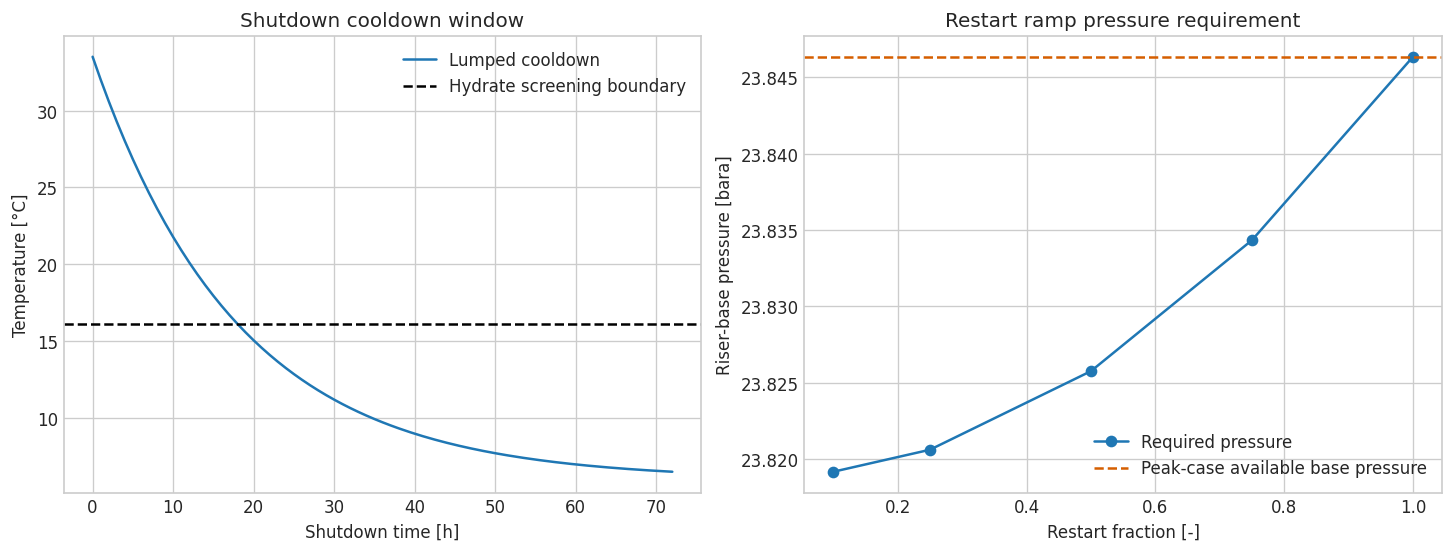

In [21]:
restart_rows = []
peak_total_rate = selected_solution["total_mass_rate_kg_s"]
for restart_fraction in [0.10, 0.25, 0.50, 0.75, 1.00]:
    restart_rate = restart_fraction * peak_total_rate
    required_base_pressure = (
        HOST_PRESSURE_BARA
        + float(riser_calibration["static_bar"])
        + float(riser_calibration["dynamic_bar_per_kg_s2"])
        * restart_rate**2
    )
    restart_rows.append(
        {
            "restart fraction": restart_fraction,
            "gathered mass rate kg/s": restart_rate,
            "required riser-base pressure bara": required_base_pressure,
            "pressure margin bar": (
                selected_solution["riser_base_pressure_bara"]
                - required_base_pressure
            ),
        }
    )
restart_table = pd.DataFrame(restart_rows)
display(restart_table)

shutdown_figure, shutdown_axes = plt.subplots(
    1,
    2,
    figsize=(12.0, 4.5),
    constrained_layout=True,
)
shutdown_axes[0].plot(
    shutdown_hours,
    cooldown_temperature_c,
    label="Lumped cooldown",
)
shutdown_axes[0].axhline(
    hydrate_boundary_c,
    color="black",
    linestyle="--",
    label="Hydrate screening boundary",
)
shutdown_axes[0].set(
    xlabel="Shutdown time [h]",
    ylabel="Temperature [°C]",
    title="Shutdown cooldown window",
)
shutdown_axes[0].legend()
shutdown_axes[1].plot(
    restart_table["restart fraction"],
    restart_table["required riser-base pressure bara"],
    marker="o",
    label="Required pressure",
)
shutdown_axes[1].axhline(
    selected_solution["riser_base_pressure_bara"],
    color="#D55E00",
    linestyle="--",
    label="Peak-case available base pressure",
)
shutdown_axes[1].set(
    xlabel="Restart fraction [-]",
    ylabel="Riser-base pressure [bara]",
    title="Restart ramp pressure requirement",
)
shutdown_axes[1].legend()
plt.show()


## 8. Volve lifecycle and NeqSim-Colab/book crosswalk

The collection is intended to teach how calculations change from
field development through operation and shutdown. The linked
[Field Development and Operations book](https://equinor.github.io/neqsimhome/doc/field_development_and_operations/book_standalone.html)
provides the general engineering narrative; the Volve notebooks
provide one data-anchored worked field case.


In [22]:
lifecycle_crosswalk = pd.DataFrame(
    [
        (
            "Discover and frame",
            "01",
            "seismic, wells, rock physics, static uncertainty",
            "volumetrics and data acquisition",
        ),
        (
            "Characterize fluids and reserves basis",
            "02",
            "NeqSim PVT, DLE, black-oil tables, reservoir contract",
            "PVT and reservoir initialization",
        ),
        (
            "Select wells and production system",
            "03 and 07",
            "IPR/VLP, nodal analysis, tubing, chokes, gathering",
            "production technology and SURF concept",
        ),
        (
            "Design facilities",
            "04",
            "separation, stabilization, compression, utilities",
            "capacity, emissions, safety, and operability",
        ),
        (
            "Operate and optimize",
            "05, 06, and 07",
            "history match, constraints, allocation, interventions",
            "digital twin, surveillance, and optimization",
        ),
        (
            "Late life and shutdown",
            "03, 05, and 07",
            "turndown, outage, cooldown, hydrate, restart, inventory",
            "integrity, cessation, and evidence for abandonment",
        ),
    ],
    columns=[
        "lifecycle stage",
        "Volve notebooks",
        "calculations",
        "decision focus",
    ],
)
display(lifecycle_crosswalk)


,lifecycle stage,Volve notebooks,calculations,decision focus
0,Discover and frame,01,"seismic, wells, rock physics, static uncertainty",volumetrics and data acquisition
1,Characterize fluids and reserves basis,02,"NeqSim PVT, DLE, black-oil tables, reservoir c...",PVT and reservoir initialization
2,Select wells and production system,03 and 07,"IPR/VLP, nodal analysis, tubing, chokes, gathe...",production technology and SURF concept
3,Design facilities,04,"separation, stabilization, compression, utilities","capacity, emissions, safety, and operability"
4,Operate and optimize,"05, 06, and 07","history match, constraints, allocation, interv...","digital twin, surveillance, and optimization"
5,Late life and shutdown,"03, 05, and 07","turndown, outage, cooldown, hydrate, restart, ...","integrity, cessation, and evidence for abandon..."


In [23]:
surf_contract_path = vc.write_contract(
    work_dir / "07_all_wells_gathering_surf.json",
    {
        "discipline": "production-technology-and-surf",
        "data_status": (
            "MEASURED_VOLVE"
            if source.measured_data_loaded
            else "DEMONSTRATION_FALLBACK"
        ),
        "production_asset": production_relative_path,
        "reservoir_handoff_status": reservoir_contract["data_status"],
        "wells_simulated": list(hydraulic_by_well.index),
        "manifolds": list(trunk_by_manifold.index),
        "nodal_records": nodal_table.to_dict("records"),
        "network_scenarios": network_summary.to_dict("records"),
        "integrity_screen": integrity_screen.to_dict("records"),
        "direct_process_verification": {
            "host_pressure_bara": direct_host_pressure_bara,
            "host_temperature_c": direct_host_temperature_c,
            "total_mass_rate_kg_s": direct_total_mass_rate_kg_s,
        },
        "shutdown": {
            "screened_liquid_inventory_m3": float(
                inventory_table[
                    "screened_liquid_inventory_m3"
                ].sum()
            ),
            "hydrate_boundary_c": hydrate_boundary_c,
            "time_to_hydrate_boundary_h": time_to_hydrate_boundary_h,
            "restart_records": restart_table.to_dict("records"),
        },
        "limitations": [
            "steady Beggs-Brill screening; no terrain transient solve",
            "screening well geometry unless measured trajectories selected",
            "linear IPR and calibrated quadratic reduced network",
            "gas-lift sensitivity is educational, not historical attribution",
            "shutdown cooldown is lumped and not an operating procedure",
        ],
    },
    source,
)
print(surf_contract_path)


/workspace/scratch/95ecac0092cf/neqsim-colab-volve/notebooks/fielddevelopment/volve/work/07_all_wells_gathering_surf.json


In [24]:
direct_mass_residual = (
    direct_total_mass_rate_kg_s
    - selected_solution["total_mass_rate_kg_s"]
) / max(selected_solution["total_mass_rate_kg_s"], 1.0e-12)
checks = {
    "every producing well has geometry": (
        set(all_wells) <= set(terminal_geometry["well"])
    ),
    "every peak well calibrated": (
        set(peak_case["well"]) == set(hydraulic_calibration["well"])
    ),
    "every peak well has a nodal crossing": (
        len(nodal_table) == len(peak_case)
    ),
    "nodal rates are positive": bool(
        nodal_table["operating_mass_rate_kg_s"].gt(0.0).all()
    ),
    "two manifolds are solved": len(trunk_by_manifold) == 2,
    "all lifecycle scenarios are finite": bool(
        np.isfinite(
            network_summary.select_dtypes(include=[np.number]).to_numpy()
        ).all()
    ),
    "all network rates are non-negative": bool(
        network_summary["total mass rate [kg/s]"].ge(0.0).all()
    ),
    "host boundary is met": bool(
        np.allclose(
            network_summary["host pressure [bara]"],
            HOST_PRESSURE_BARA,
            atol=1.0e-6,
        )
    ),
    "ProcessSystem mass closes": abs(direct_mass_residual) < 1.0e-8,
    "direct host pressure is physical": direct_host_pressure_bara > 1.0,
    "reduced and direct host pressure agree": (
        abs(direct_host_pressure_bara - HOST_PRESSURE_BARA) < 5.0
    ),
    "pressure profiles are finite": all(
        np.isfinite(
            np.asarray(pipe.getPressureProfile(), dtype=float)
        ).all()
        for pipe in [
            *tubing_pipes.values(),
            *branch_pipes.values(),
            *trunk_pipes.values(),
            riser,
        ]
    ),
    "velocity margins are finite": bool(
        np.isfinite(integrity_screen["velocity_margin_m_s"]).all()
    ),
    "shutdown inventory is positive": bool(
        inventory_table["screened_liquid_inventory_m3"].sum() > 0.0
    ),
    "hydrate crossing occurs after shutdown": (
        time_to_hydrate_boundary_h > 0.0
    ),
    "restart ramp is ordered": bool(
        restart_table[
            "required riser-base pressure bara"
        ].is_monotonic_increasing
    ),
    "handoff exists": surf_contract_path.is_file(),
}
validation = pd.DataFrame(
    {"check": checks.keys(), "passed": checks.values()}
)
display(validation)
failed_checks = validation.loc[~validation["passed"], "check"].tolist()
if failed_checks:
    raise AssertionError(failed_checks)
print(f"All {len(checks)} all-well and full-SURF checks passed.")


All 17 all-well and full-SURF checks passed.


,check,passed
0,every producing well has geometry,True
1,every peak well calibrated,True
2,every peak well has a nodal crossing,True
3,nodal rates are positive,True
4,two manifolds are solved,True
5,all lifecycle scenarios are finite,True
6,all network rates are non-negative,True
7,host boundary is met,True
8,ProcessSystem mass closes,True
9,direct host pressure is physical,True


## Results, limitations, and operating decisions

Every producing well is represented by a named reservoir node,
tubing, branch, nodal operating point, and manifold connection. The
gathering system solves common backpressure, two trunks, one riser,
and the facility inlet before a full NeqSim process verifies the
selected point. Scenario results show how depletion, water handling,
well outages, and turndown migrate the active constraint.

The shutdown screen quantifies trapped liquid inventory, cooldown
time to a hydrate boundary, and a restart pressure ramp. It does not
replace operating procedures, dynamic multiphase simulation,
safeguards, barrier management, corrosion/erosion inspection,
emergency depressurization, or regulatory assurance. Those remain
explicit decisions and evidence needs in the Volve lifecycle map.


## Notebook validation evidence

Validation requires a clean top-to-bottom run with stored outputs
for all wells, both manifolds, trunks, riser, lifecycle cases,
ProcessSystem verification, integrity tables, shutdown inventory,
cooldown, and restart. The rendered notebook must be inspected for
every equation, table, layout, nodal plot, profile, scenario plot,
and shutdown plot.

Evidence level: NeqSim multiphase thermodynamics and Beggs–Brill
execution, all-well nodal intersections, coupled network root solves,
direct ProcessSystem mass closure, hydraulic profiles, physical
bounds, lifecycle sensitivities, and explicit transient limitations.
